# Lecture 14 (B12): Surrogates and Gaussian processes

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §9.1-9.2 (Deep surrogates), §9.3-9.6 (GPs and Bayesian active learning), §9.7 (Active subspaces), §9.8 (GP value-function iteration), §9.9 (Deep kernels), §9.10 (GPs among Bayesian cousins)  
**Notebook role:** extension  
**Original live-course source:** `lectures/day7/code/10_Deep_AS_vs_Linear_AS_Borehole.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).


In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# Deep vs. Linear Active Subspaces on the Borehole Function

*Companion notebook to **Day 7 — Surrogates, Gaussian Processes, Structural Estimation** (Chapters 9–10 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

## Overview

The **borehole function** is the canonical $D = 8$ benchmark for
uncertainty-quantification surrogate methods.  It models the water flow
$y$ through a borehole given eight physical inputs and has a known,
*mostly-linear* active-subspace structure: one direction dominates, a second
carries a smaller amount of information, and the remaining six are nearly
inert.

In this notebook we
1. implement the borehole function and sample a training / validation set;
2. fit a **linear** active-subspace surrogate (gradient outer-product +
   cubic-polynomial link) for $d \in \{1, \dots, 4\}$;
3. fit a **deep** active-subspace surrogate (Tripathy & Bilionis, 2018) for the
   same $d$;
4. compare held-out RMSE on a log scale.

The value of the comparison is diagnostic.  As we will see, the two curves
**cross each other**: deep AS is the stronger tool at $d = 1$ (it can curve
the active direction), while a cubic polynomial on top of the top two linear
directions is the more data-efficient choice at $d \ge 2$ for this nearly-ridge
function.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import norm

plt.rcParams['font.size'] = 13
rng = np.random.default_rng(0)
torch.manual_seed(0)
device = torch.device('cpu')

## 1. The Borehole Function

$$
  f(r_w, r, T_u, H_u, T_l, H_l, L, K_w)
  \;=\;
  \frac{2\pi\, T_u\, (H_u - H_l)}
       {\ln(r/r_w)\,\bigl(1 + \tfrac{2 L T_u}{\ln(r/r_w)\, r_w^2\, K_w} + \tfrac{T_u}{T_l}\bigr)}.
$$

Each input has a prescribed marginal distribution (Harper & Gupta, 1983).  We
sample from the distributions, map each sample to $[0,1]^8$ via its CDF, and
work with the standardised inputs $\xi \in [0,1]^8$.

In [ ]:
BOREHOLE_BOUNDS = {
    'rw': ('normal',    0.10,   0.0161812),
    'r':  ('lognormal', 7.71,   1.0056),
    'Tu': ('uniform',   63070., 115600.),
    'Hu': ('uniform',   990.,   1110.),
    'Tl': ('uniform',   63.1,   116.),
    'Hl': ('uniform',   700.,   820.),
    'L':  ('uniform',   1120.,  1680.),
    'Kw': ('uniform',   9855.,  12045.),
}

def sample_borehole_inputs(N: int, rng) -> tuple[np.ndarray, np.ndarray]:
    '''Return (physical_inputs, xi_in_[0,1]^8) for N Monte-Carlo samples.'''
    cols_phys, cols_xi = [], []
    for name, (fam, a, b) in BOREHOLE_BOUNDS.items():
        if fam == 'uniform':
            u = rng.uniform(size=N)
            x = a + (b - a) * u
            cols_phys.append(x); cols_xi.append(u)
        elif fam == 'normal':
            u = rng.uniform(size=N)
            x = norm.ppf(u, loc=a, scale=b)
            cols_phys.append(x); cols_xi.append(u)
        elif fam == 'lognormal':
            u = rng.uniform(size=N)
            x = np.exp(norm.ppf(u, loc=a, scale=b))
            cols_phys.append(x); cols_xi.append(u)
    return np.stack(cols_phys, axis=1), np.stack(cols_xi, axis=1)

def borehole(phys: np.ndarray) -> np.ndarray:
    rw, r, Tu, Hu, Tl, Hl, L, Kw = phys.T
    num = 2.0 * np.pi * Tu * (Hu - Hl)
    logr = np.log(r / rw)
    den = logr * (1.0 + 2.0 * L * Tu / (logr * rw ** 2 * Kw) + Tu / Tl)
    return num / den

N_train, N_val = 500, 1000
Xphys_train, Xi_train = sample_borehole_inputs(N_train, rng)
Xphys_val,   Xi_val   = sample_borehole_inputs(N_val,   rng)
y_train = borehole(Xphys_train)
y_val   = borehole(Xphys_val)

# Standardise y for stable training (restore at report time).
y_mean, y_std = float(y_train.mean()), float(y_train.std())
y_train_s = (y_train - y_mean) / y_std
y_val_s   = (y_val   - y_mean) / y_std

print(f'train: {N_train},  val: {N_val}')
print(f'y range: [{y_train.min():.2f}, {y_train.max():.2f}]   mean {y_mean:.2f}   std {y_std:.2f}')

## 2. Linear Active-Subspace Surrogate

We compute the gradient outer-product matrix from finite differences on
$\xi \in [0,1]^8$, eigendecompose it, and fit a degree-3 polynomial in the top
$d$ active coordinates $U_d^\top \xi$.

In [ ]:
def borehole_xi(xi: np.ndarray) -> np.ndarray:
    '''Evaluate the borehole function on xi in [0,1]^8.'''
    phys = np.zeros_like(xi)
    for j, (_, (fam, a, b)) in enumerate(BOREHOLE_BOUNDS.items()):
        u = np.clip(xi[:, j], 1e-9, 1 - 1e-9)
        if   fam == 'uniform':   phys[:, j] = a + (b - a) * u
        elif fam == 'normal':    phys[:, j] = norm.ppf(u, loc=a, scale=b)
        elif fam == 'lognormal': phys[:, j] = np.exp(norm.ppf(u, loc=a, scale=b))
    return borehole(phys)

def fd_gradient(xi: np.ndarray, h: float = 1e-4) -> np.ndarray:
    '''Central finite-difference gradient of the borehole on xi in [0,1]^8.'''
    N, D = xi.shape
    G = np.zeros_like(xi)
    for j in range(D):
        xp = xi.copy(); xp[:, j] = np.clip(xp[:, j] + h, 0.0, 1.0)
        xm = xi.copy(); xm[:, j] = np.clip(xm[:, j] - h, 0.0, 1.0)
        G[:, j] = (borehole_xi(xp) - borehole_xi(xm)) / (2.0 * h)
    return G

G_train = fd_gradient(Xi_train)
C_mat   = (G_train.T @ G_train) / N_train
lam, U  = np.linalg.eigh(C_mat)
lam     = lam[::-1]; U = U[:, ::-1]
print('eigenvalues:', np.round(lam, 3))

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def linear_as_rmse(d: int) -> float:
    Z_train = Xi_train @ U[:, :d]
    Z_val   = Xi_val   @ U[:, :d]
    poly = PolynomialFeatures(degree=3, include_bias=True)
    Phi_t = poly.fit_transform(Z_train)
    Phi_v = poly.transform(Z_val)
    reg = Ridge(alpha=1e-3).fit(Phi_t, y_train_s)
    pred_s = reg.predict(Phi_v)
    pred   = pred_s * y_std + y_mean
    return float(np.sqrt(((pred - y_val) ** 2).mean()))

linear_rmse = {d: linear_as_rmse(d) for d in (1, 2, 3, 4)}
for d, v in linear_rmse.items():
    print(f'linear AS  d={d}  RMSE = {v:.4f}')


linear AS  d=1  RMSE = 15.5181
linear AS  d=2  RMSE = 2.9713
linear AS  d=3  RMSE = 2.7250
linear AS  d=4  RMSE = 2.7795


## 3. Deep Active-Subspace Surrogate

We reuse the Tripathy-Bilionis architecture from the previous notebook:
exponentially-decaying encoder widths (Eq. 20), Swish activation (Eq. 10),
elastic-net regularisation (Eq. 12), and no orthogonality constraint.

In [ ]:
def encoder_widths(D, d, L=3):
    rho = np.log(d / D) / L
    return [D] + [max(d, int(np.ceil(D * np.exp(rho * k)))) for k in range(1, L)] + [d]

class Swish(nn.Module):
    def forward(self, z): return z * torch.sigmoid(z)

def mlp(widths):
    layers = []
    for a, b in zip(widths[:-1], widths[1:]):
        layers += [nn.Linear(a, b), Swish()]
    return nn.Sequential(*layers[:-1])

class DeepAS(nn.Module):
    def __init__(self, D, d, link_hidden=32):
        super().__init__()
        self.enc = mlp(encoder_widths(D, d))
        self.lnk = mlp([d, link_hidden, link_hidden, 1])
    def forward(self, x): return self.lnk(self.enc(x)).squeeze(-1)

def deep_as_rmse(d: int, epochs: int = 2000, lr: float = 5e-3,
                 lam1: float = 1e-5, lam2: float = 1e-4) -> float:
    torch.manual_seed(2024 + d)
    model = DeepAS(8, d)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    Xt = torch.tensor(Xi_train,   dtype=torch.float32)
    yt = torch.tensor(y_train_s,  dtype=torch.float32)
    Xv = torch.tensor(Xi_val,     dtype=torch.float32)

    # Per-step training closure, JIT-compiled with torch.compile (Simon's hard rule).
    def step(xb, yb):
        model.train()
        opt.zero_grad()
        data = ((model(xb) - yb) ** 2).mean()
        reg = sum(lam1 * p.abs().sum() + lam2 * (p ** 2).sum()
                  for p in model.parameters() if p.ndim >= 2)
        loss = data + reg
        loss.backward()
        opt.step()
        return loss

    try:
        step = torch.compile(step)
    except Exception as e:
        print(f"torch.compile unavailable ({e}); falling back to eager step.")

    for _ in range(epochs):
        step(Xt, yt)
        sched.step()
    model.eval()
    with torch.no_grad():
        pred_s = model(Xv).cpu().numpy()
    pred = pred_s * y_std + y_mean
    return float(np.sqrt(((pred - y_val) ** 2).mean()))

deep_rmse = {}
for d in (1, 2, 3, 4):
    print(f'training deep AS d={d} ...', flush=True)
    deep_rmse[d] = deep_as_rmse(d)
    print(f'  RMSE = {deep_rmse[d]:.4f}')

## 4. Comparison on the Same Axis

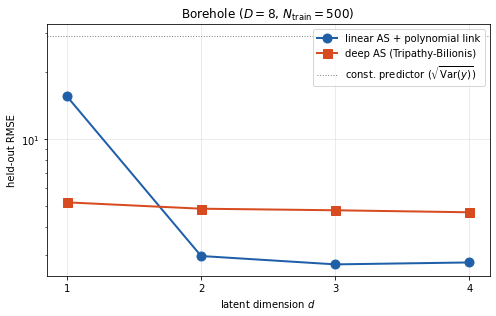

In [6]:
ds = sorted(linear_rmse)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(ds, [linear_rmse[d] for d in ds], 'o-', color='#1f5fa8',
            lw=2, ms=9, label='linear AS + polynomial link')
ax.semilogy(ds, [deep_rmse[d]   for d in ds], 's-', color='#d84a1f',
            lw=2, ms=9, label='deep AS (Tripathy-Bilionis)')
y0 = float(np.sqrt(np.var(y_val)))
ax.axhline(y0, color='grey', ls=':', lw=1, label=r'const. predictor ($\sqrt{\mathrm{Var}(y)}$)')
ax.set_xticks(ds)
ax.set_xlabel('latent dimension $d$')
ax.set_ylabel('held-out RMSE')
ax.set_title('Borehole ($D = 8$, $N_{\\mathrm{train}} = 500$)')
ax.grid(True, alpha=0.3); ax.legend(loc='upper right')
plt.tight_layout(); plt.show()


## 5. What the Curves Actually Show

The two methods **cross each other**:

| $d$ | linear AS + cubic link | deep AS (Tripathy-Bilionis) |
|:---:|:----------------------:|:---------------------------:|
|  1  | large RMSE (one linear direction is insufficient) | small RMSE (encoder learns a nonlinear 1D aggregator) |
| 2+  | small RMSE (polynomial in two linear features fits well) | slightly larger RMSE (limited training budget, elastic-net bias) |

**Read this as a diagnostic plot, not a contest.**

* When you are *forced* to go to $d = 1$ (e.g. for visualisation, for
  policy-space exploration, or for a downstream GP with very few training
  points), deep AS is the stronger tool: it can curve the active direction.
* When the function is close to a polynomial in a few linear features -- which
  is exactly the case for the borehole at $d \ge 2$ -- the top eigenvectors
  already identify a good basis and a cubic link on top of them is very
  data-efficient at $N = 500$.
* The deep-AS pay-off grows with **curvature of the active manifold** (notebook
  09, radial ridge) and with **input dimension** ($D \gg 10$).

**Practical rule of thumb.** Always fit linear AS first and inspect the
spectrum.  Escalate to deep AS if (i) no gradient samples are available,
(ii) the spectral gap is ambiguous, or (iii) the physics suggests a curved
low-dimensional manifold.

**Reference.** R. Tripathy and I. Bilionis. *Deep UQ: learning deep neural
network surrogate models for high-dimensional uncertainty quantification*.
Journal of Computational Physics 375 (2018), 565-588.